In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""peru""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_MANE_CADD_251110.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']
# existing_annos = ['am_pathogenicity']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -0
max_range = +500

anno = (
    anno
    .filter(
        #
        (pl.col('consequence_5_prime_utr_variant')==1) &
        # Filter for non-coding variants
        # (pl.col('vep_cds') == False) &
        # (pl.col('mane_cds') == False) &
        # (pl.col('non_mane_cds') == False) &

        # Filter for coding variants
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True)) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

tss,gpn_star_llr_calibrated_mean,gene_name,gene_length,pangolin_score,strand,region,loftee_hc,verphylop,esmscoremissense,score_pai3d,gpn_score,dist_to_tss,mamphylop,cadd_raw,absplice_dna_max,absplice2_max,am_pathogenicity,promoterai,delta_score,id
i64,f32,str,i64,f64,str,str,i8,f32,f32,f32,f32,i64,f32,f32,f64,f64,f32,f32,f64,str
100367529,-1.405161,"""PILRA""",32568,0.0,"""1""","""ENSG00000085514""",0,-0.303,null,null,-3.2,17,-0.326,0.364045,0.005,0.000469,null,-0.0738,null,"""chr7:100367546:A:G"""
100367529,-1.061941,"""PILRA""",32568,0.0,"""1""","""ENSG00000085514""",0,0.598,null,null,-1.9,14,0.595,0.549139,0.004,0.000332,null,0.0852,null,"""chr7:100367543:A:G"""
40465764,-0.457986,"""BLVRB""",18001,0.0,"""-1""","""ENSG00000090013""",0,0.498,null,null,-1.4,52,0.974,1.151221,0.001,0.000033,null,-0.3641,0.0,"""chr19:40465712:G:A"""
40465764,0.249177,"""BLVRB""",18001,0.0,"""-1""","""ENSG00000090013""",0,-0.012,null,null,-1.31,62,0.076,0.550017,0.004,0.000504,null,-0.0084,0.0,"""chr19:40465702:G:C"""
100367529,0.464833,"""PILRA""",32568,0.0,"""1""","""ENSG00000085514""",0,-0.358,null,null,-0.54,53,-0.368,0.291898,0.007,0.000636,null,-0.0058,null,"""chr7:100367582:C:T"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
247416155,1.364413,"""NLRP3""",32954,null,"""1""","""ENSG00000162711""",0,null,null,null,0.88,-42088,null,0.244923,null,null,null,null,null,"""chr1:247374067:C:G"""
247416155,1.599912,"""NLRP3""",32954,null,"""1""","""ENSG00000162711""",0,null,null,null,-0.54,-83756,null,0.746788,null,null,null,null,null,"""chr1:247332399:C:G"""
247416155,0.277689,"""NLRP3""",32954,null,"""1""","""ENSG00000162711""",0,null,null,null,-0.53,-83794,null,0.207359,null,null,null,null,null,"""chr1:247332361:G:C"""


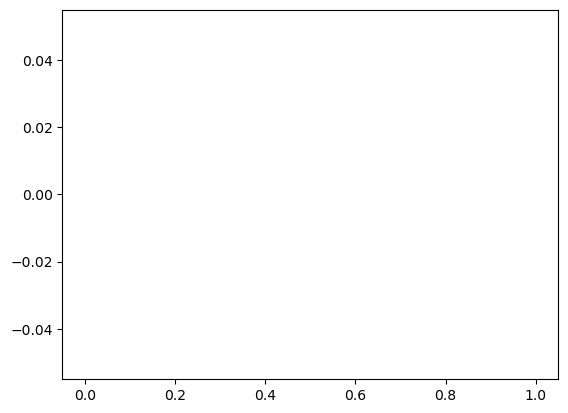

In [4]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [5]:
melted_anno = (
    anno
    .unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null()) &

        # Filter based on category
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'missense'])
        # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation']))
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_count = pl.len().over(["region", "annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i8,f32,f32
"""chr4:72032080:G:T""","""ENSG00000056291""","""score_pai3d""",0.155379,"""missense""","""peru""","""PrimateAI-3D""",1,11.0,0.157143
"""chr4:72032076:C:T""","""ENSG00000056291""","""score_pai3d""",0.374726,"""missense""","""peru""","""PrimateAI-3D""",1,63.0,0.9
"""chr4:72032152:G:A""","""ENSG00000056291""","""score_pai3d""",0.239191,"""missense""","""peru""","""PrimateAI-3D""",1,33.0,0.471429
"""chr4:72032056:G:A""","""ENSG00000056291""","""score_pai3d""",0.284779,"""missense""","""peru""","""PrimateAI-3D""",1,45.0,0.642857
"""chr4:72032130:G:T""","""ENSG00000056291""","""score_pai3d""",0.465451,"""missense""","""peru""","""PrimateAI-3D""",1,67.0,0.957143
…,…,…,…,…,…,…,…,…,…
"""chr10:32958162:C:T""","""ENSG00000150093""","""absplice2_max""",0.000351,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,71.0,0.522059
"""chr10:32958170:G:C""","""ENSG00000150093""","""absplice2_max""",0.000462,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,114.5,0.841912
"""chr10:32958174:C:T""","""ENSG00000150093""","""absplice2_max""",0.000428,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,97.5,0.716912


In [6]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_ptile'])
    .agg(
        n_vars_at_ptile = pl.len()
    )
    .sort('annotation_score_dircor_ptile', descending=True)
    .with_columns(
        n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_ptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,str,str,i8,f32,f32,u64,u64
"""chr4:72032080:G:T""","""ENSG00000056291""","""score_pai3d""",0.155379,"""missense""","""peru""","""PrimateAI-3D""",1,11.0,0.157143,1,155
"""chr4:72032076:C:T""","""ENSG00000056291""","""score_pai3d""",0.374726,"""missense""","""peru""","""PrimateAI-3D""",1,63.0,0.9,1,20
"""chr4:72032152:G:A""","""ENSG00000056291""","""score_pai3d""",0.239191,"""missense""","""peru""","""PrimateAI-3D""",1,33.0,0.471429,1,98
"""chr4:72032056:G:A""","""ENSG00000056291""","""score_pai3d""",0.284779,"""missense""","""peru""","""PrimateAI-3D""",1,45.0,0.642857,2,67
"""chr4:72032130:G:T""","""ENSG00000056291""","""score_pai3d""",0.465451,"""missense""","""peru""","""PrimateAI-3D""",1,67.0,0.957143,1,9
…,…,…,…,…,…,…,…,…,…,…,…
"""chr10:32958162:C:T""","""ENSG00000150093""","""absplice2_max""",0.000351,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,71.0,0.522059,1,31470
"""chr10:32958170:G:C""","""ENSG00000150093""","""absplice2_max""",0.000462,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,114.5,0.841912,4,12413
"""chr10:32958174:C:T""","""ENSG00000150093""","""absplice2_max""",0.000428,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,97.5,0.716912,30,21241


In [7]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_ptile').max(),
).sort('n_vars', descending=True)

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""cadd_raw""",83151,1.0
"""gpn_score""",83151,1.0
"""gpn_star_llr_calibrated_mean""",83151,1.0
"""mamphylop""",82970,1.0
"""verphylop""",82970,1.0
…,…,…
"""pangolin_score""",80173,1.0
"""absplice_dna_max""",66605,1.0
"""delta_score""",59113,1.0


In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [10]:
n_steps = 100
min_rank_cutoff = 1_000
max_rank_cutoff = 500_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

cutoffs_list = np.geomspace(
# cutoffs_list = np.linspace(
    min_rank_cutoff, 
    max_rank_cutoff, 
    num=n_steps
).tolist()

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": cutoffs_list})

cutoffs_lazy.collect()

rank_cutoff
f64
1000.0
1045.66507
1093.415438
1143.346331
1195.557321
…
69549.990252
72725.995414
76047.033074


In [11]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff')
# or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""pangolin_score""","""ENSG00000196739""","""COL27A1""","""basal_metabolic_rate_int""",1000.0,0,1,2,125,0.0
"""absplice_dna_max""","""ENSG00000024048""","""UBR2""","""body_fat_percentage_int""",1000.0,0,2,0,68,NaN
"""pangolin_score""","""ENSG00000163631""","""ALB""","""calcium_int""",1000.0,0,1,0,9,NaN
"""delta_score""","""ENSG00000143365""","""RORC""","""creactive_protein_int""",1000.0,0,0,0,10,NaN
"""pangolin_score""","""ENSG00000131183""","""SLC34A1""","""creatinine_int""",1000.0,0,0,1,51,NaN
…,…,…,…,…,…,…,…,…,…
"""gpn_star_llr_calibrated_mean""","""ENSG00000140443""","""IGF1R""","""whole_body_fatfree_mass_int""",83151.0,4,573,0,0,NaN
"""absplice_dna_max""","""ENSG00000140443""","""IGF1R""","""whole_body_water_mass_int""",83151.0,2,306,0,0,NaN
"""absplice2_max""","""ENSG00000173575""","""CHD2""","""white_blood_cell_leukocyte_cou…",83151.0,0,174,0,0,NaN


## Plotting

In [12]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'rank_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('rank_cutoff')
)

plt_df

unique percentile cutoffs: 100


annotation,rank_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""pangolin_score""",1000.0,476,0.0,0.919428,0.355988,1.617165,0.221691,"""#28a745""","""Pangolin"""
"""gpn_score""",1000.0,480,0.0,2.495978,0.635994,3.742525,1.249431,"""pink""","""GPN-MSA"""
"""absplice2_max""",1000.0,473,0.0,0.335447,0.265026,0.854898,-0.184003,"""#28a745""","""AbSplice2 (max)"""
"""absplice_dna_max""",1000.0,386,0.0,0.545337,0.260277,1.05548,0.035194,"""#28a745""","""AbSplice (max)"""
"""mamphylop""",1000.0,428,0.0,1.264875,0.410188,2.068843,0.460907,"""#942c80""","""Mammalian PhyloP"""
…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",79519.726151,64,0.053517,0.074084,0.01056,0.094782,0.053386,"""#1f77b4""","""CADD Raw"""
"""gpn_score""",79519.726151,76,0.062379,0.097901,0.011439,0.120321,0.07548,"""pink""","""GPN-MSA"""
"""verphylop""",79519.726151,70,0.080293,0.102852,0.012484,0.12732,0.078383,"""#942c80""","""Vertebrate PhyloP"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10


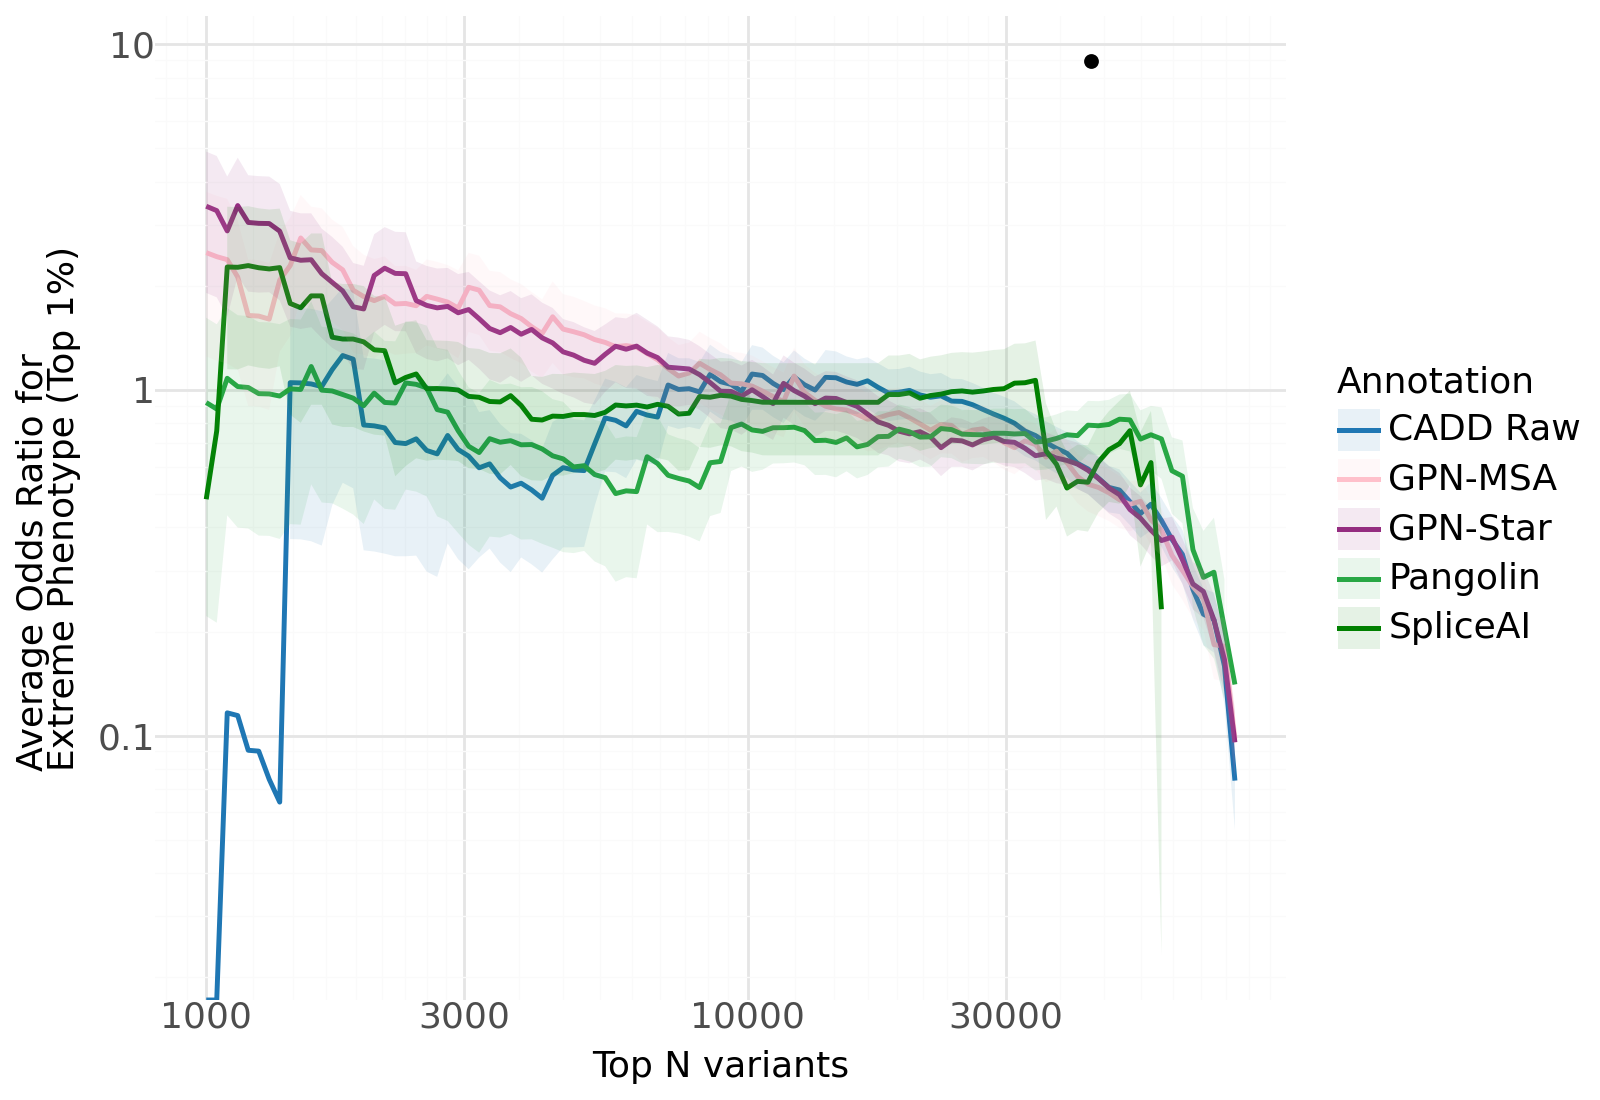

In [13]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = int((1-or_threshold_pheno)*100)

# am_lof_df = pl.DataFrame({
#     'annotation': ['loftee_coding', 'am_0.8_coding'],
#     'n_vars': [21519, 56609],
#     'mean_or': [6.874422, 2.323273],
#     'median_or': [3.04127, 1.770242],
# })

am_lof_df = pl.DataFrame({
    'annotation': ['loftee_coding', 'am_0.8_coding'],
    'n_vars': [43179, 57191],
    'mean_or': [8.963194, 3.196688],
    'median_or': [3.724961, 1.955789],
})

(
    ggplot(
        # plt_df,
        plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'gpn_score', 'pangolin_score', 'delta_score', 'am_pathogenicity', 'score_pai3d'])),
        # plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'pangolin_score', 'delta_score'])),
        aes(x='rank_cutoff', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    # + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_log10()
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)